# Finding Donors for CharityML
## Supervised learning: exploration, comparison, tuning, and feature selection

**Objective:** Predict income above $50,000 as a proxy for identifying potential donors.
Actual donation propensity and revenue cannot be measured from this income dataset.

**Environment:** Python 3.12.14; package versions are printed below. The core packages match
the assignment's versions. All results are computed by executing this notebook.

**Metric convention:** F-score means **F₀.₅** throughout the notebook, as required by its
instructions. **F₁** is also reported to satisfy the supplied rubric's wording.
Random seeds are fixed at 0. Timing results describe this machine and may vary.

This notebook completes all implementation sections and Questions 1–8 from Udacity's
[starter project](https://github.com/udacity/cd0025-supervised-learning).
The supplied `visuals.py` is used without modification.

Run all cells in order with `census.csv` and `visuals.py` in the working directory.
The optional final section uses the supplied `test_census.csv` and
`example_submission.csv`; it creates predictions locally and does not submit to Kaggle.

## Getting Started

In this project, you will employ several supervised algorithms of your choice to accurately model individuals' income using data collected from the 1994 U.S. Census. You will then choose the best candidate algorithm from preliminary results and further optimize this algorithm to best model the data. Your goal with this implementation is to construct a model that accurately predicts whether an individual makes more than $50,000. This sort of task can arise in a non-profit setting, where organizations survive on donations.  Understanding an individual's income can help a non-profit better understand how large of a donation to request, or whether or not they should reach out to begin with.  While it can be difficult to determine an individual's general income bracket directly from public sources, we can (as we will see) infer this value from other publically available features. 

The dataset for this project originates from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/Census+Income). The datset was donated by Ron Kohavi and Barry Becker, after being published in the article _"Scaling Up the Accuracy of Naive-Bayes Classifiers: A Decision-Tree Hybrid"_. You can find the article by Ron Kohavi [online](https://www.aaai.org/Papers/KDD/1996/KDD96-033.pdf). The data we investigate here consists of small changes to the original dataset, such as removing the `fnlwgt` feature and records with missing or ill-formatted entries.

----
## Exploring the Data
Run the code cell below to load necessary Python libraries and load the census data. Note that the last column from this dataset, `income`, will be our target label (whether an individual makes more than, or at most, $50,000 annually). All other columns are features about each individual in the census database.

In [1]:
import sys
import json
from pathlib import Path
from time import perf_counter as time
import numpy as np
import pandas as pd
import sklearn
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display
%matplotlib inline
import visuals as vs

print('Python:', sys.version.split()[0])
print('numpy:', np.__version__, '| pandas:', pd.__version__,
      '| scikit-learn:', sklearn.__version__, '| matplotlib:', matplotlib.__version__)
pd.set_option('display.max_columns', 20)
data = pd.read_csv('census.csv', skipinitialspace=True, na_values=['?', ''])
for col in data.select_dtypes(include='object'):
    data[col] = data[col].str.strip()
assert set(data['income'].unique()) == {'<=50K', '>50K'}
print('Missing entries:', int(data.isna().sum().sum()))
print('Duplicate rows (retained; no person identifier):', int(data.duplicated().sum()))
display(data.head(1))

Python: 3.12.14
numpy: 1.26.3 | pandas: 2.1.4 | scikit-learn: 1.4.0 | matplotlib: 3.8.2


Missing entries: 0
Duplicate rows (retained; no person identifier): 5982


,age,workclass,education_level,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,2174.0,0.0,40.0,United-States,<=50K


### Implementation: Data Exploration
A cursory investigation of the dataset will determine how many individuals fit into either group, and will tell us about the percentage of these individuals making more than \$50,000. In the code cell below, you will need to compute the following:
- The total number of records, `n_records`
- The number of individuals making more than \$50,000 annually, `n_greater_50k`.
- The number of individuals making at most \$50,000 annually, `n_at_most_50k`.
- The percentage of individuals making more than \$50,000 annually, `greater_percent`.

**HINT:** You may need to look at the table above to understand how the `income` entries are formatted. 

In [2]:
n_records = len(data)
n_greater_50k = int(data['income'].eq('>50K').sum())
n_at_most_50k = int(data['income'].eq('<=50K').sum())
greater_percent = 100 * n_greater_50k / n_records
assert n_records == n_greater_50k + n_at_most_50k
print(f'Total number of records: {n_records:,}')
print(f'Individuals making more than $50,000: {n_greater_50k:,}')
print(f'Individuals making at most $50,000: {n_at_most_50k:,}')
print(f'Percentage making more than $50,000: {greater_percent:.4f}%')

Total number of records: 45,222
Individuals making more than $50,000: 11,208
Individuals making at most $50,000: 34,014
Percentage making more than $50,000: 24.7844%


**Featureset Exploration**

* **age**: continuous. 
* **workclass**: Private, Self-emp-not-inc, Self-emp-inc, Federal-gov, Local-gov, State-gov, Without-pay, Never-worked. 
* **education**: Bachelors, Some-college, 11th, HS-grad, Prof-school, Assoc-acdm, Assoc-voc, 9th, 7th-8th, 12th, Masters, 1st-4th, 10th, Doctorate, 5th-6th, Preschool. 
* **education-num**: continuous. 
* **marital-status**: Married-civ-spouse, Divorced, Never-married, Separated, Widowed, Married-spouse-absent, Married-AF-spouse. 
* **occupation**: Tech-support, Craft-repair, Other-service, Sales, Exec-managerial, Prof-specialty, Handlers-cleaners, Machine-op-inspct, Adm-clerical, Farming-fishing, Transport-moving, Priv-house-serv, Protective-serv, Armed-Forces. 
* **relationship**: Wife, Own-child, Husband, Not-in-family, Other-relative, Unmarried. 
* **race**: Black, White, Asian-Pac-Islander, Amer-Indian-Eskimo, Other. 
* **sex**: Female, Male. 
* **capital-gain**: continuous. 
* **capital-loss**: continuous. 
* **hours-per-week**: continuous. 
* **native-country**: United-States, Cambodia, England, Puerto-Rico, Canada, Germany, Outlying-US(Guam-USVI-etc), India, Japan, Greece, South, China, Cuba, Iran, Honduras, Philippines, Italy, Poland, Jamaica, Vietnam, Mexico, Portugal, Ireland, France, Dominican-Republic, Laos, Ecuador, Taiwan, Haiti, Columbia, Hungary, Guatemala, Nicaragua, Scotland, Thailand, Yugoslavia, El-Salvador, Trinadad&Tobago, Peru, Hong, Holand-Netherlands.

----
## Preparing the Data
Before data can be used as input for machine learning algorithms, it often must be cleaned, formatted, and restructured — this is typically known as **preprocessing**. Fortunately, for this dataset, there are no invalid or missing entries we must deal with, however, there are some qualities about certain features that must be adjusted. This preprocessing can help tremendously with the outcome and predictive power of nearly all learning algorithms.

### Transforming Skewed Continuous Features
A dataset may sometimes contain at least one feature whose values tend to lie near a single number, but will also have a non-trivial number of vastly larger or smaller values than that single number.  Algorithms can be sensitive to such distributions of values and can underperform if the range is not properly normalized. With the census dataset two features fit this description: `capital-gain` and `capital-loss`. 

Run the code cell below to plot a histogram of these two features. Note the range of the values present and how they are distributed.

C:\Users\mwqas\OneDrive\Desktop\Finding Donors\finding_donors\visuals.py:50: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


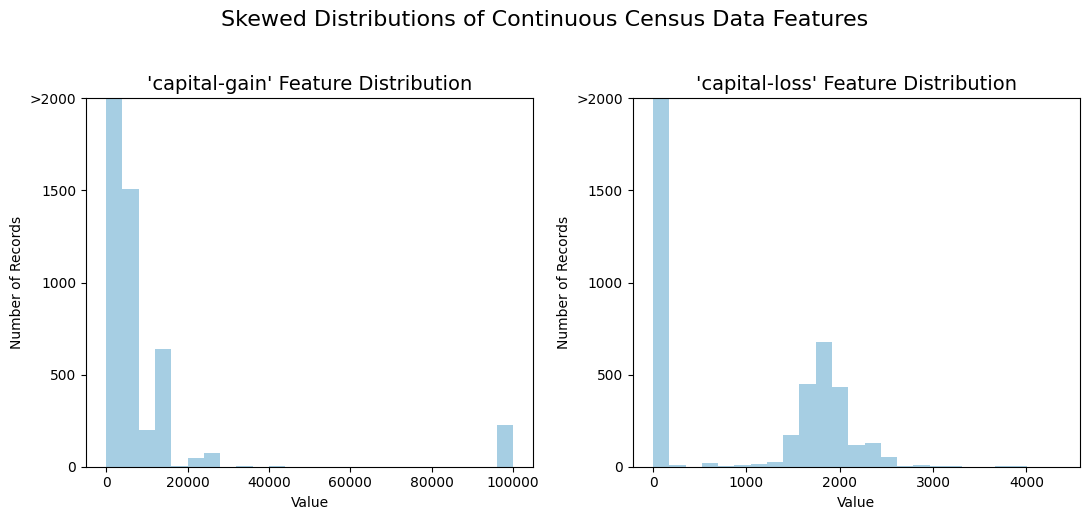

In [3]:
# Split the data into features and target label
income_raw = data['income']
features_raw = data.drop('income', axis = 1)

# Visualize skewed continuous features of original data
vs.distribution(data)

For highly-skewed feature distributions such as `capital-gain` and `capital-loss`, it is common practice to apply a [logarithmic transformation](https://en.wikipedia.org/wiki/Data_transformation_(statistics)) on the data so that the very large and very small values do not negatively affect the performance of a learning algorithm. Using a logarithmic transformation significantly reduces the range of values caused by outliers. Care must be taken when applying this transformation however: The logarithm of 0 is undefined, so we must translate the values by a small amount above 0 to apply the the logarithm successfully.

Run the code cell below to perform a transformation on the data and visualize the results. Again, note the range of values and how they are distributed. 

C:\Users\mwqas\OneDrive\Desktop\Finding Donors\finding_donors\visuals.py:50: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


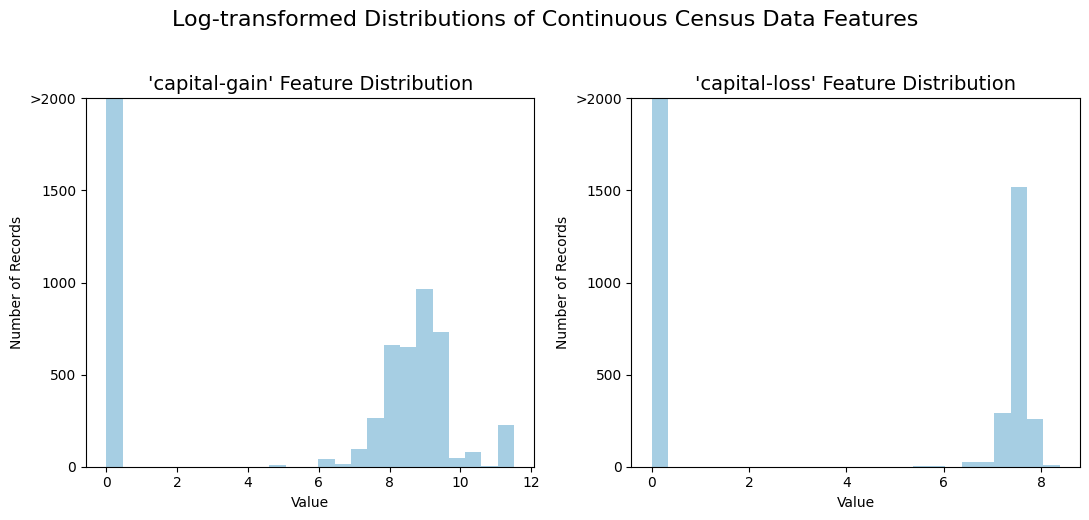

In [4]:
skewed = ['capital-gain', 'capital-loss']
features_log_transformed = features_raw.copy()
features_log_transformed[skewed] = np.log1p(features_raw[skewed])
vs.distribution(features_log_transformed, transformed=True)

### Normalizing Numerical Features

The split is established **before fitting preprocessing**. Log1p is a fixed transformation;
medians, modes, scaling limits, and the modeling feature schema are learned only from training
rows. Min–max scaling makes numeric ranges comparable. Holdout values may legitimately
fall outside [0, 1] when they exceed training extrema.

The reusable transformer below also handles missing competition data. It uses pandas
one-hot encoding, aligns columns to the training schema, and represents unseen categories
with zeros in that feature's indicator columns. During cross-validation the entire
transformer is refitted inside each fold through a Pipeline, following
[scikit-learn's leakage guidance](https://scikit-learn.org/1.4/common_pitfalls.html#data-leakage).

In [5]:
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.validation import check_is_fitted

numerical = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
income = income_raw.map({'<=50K': 0, '>50K': 1}).astype(int)
train_idx, test_idx = train_test_split(
    data.index, test_size=0.2, random_state=0, stratify=income)

class CensusPreprocessor(BaseEstimator, TransformerMixin):
    """Learn imputation, min-max scaling, and dummy columns from training rows."""
    def fit(self, X, y=None):
        self.input_columns_ = list(X.columns)
        self.numeric_ = list(numerical)
        self.categorical_ = [c for c in X if c not in self.numeric_]
        clean = self._clean(X)
        self.medians_ = clean[self.numeric_].median()
        self.modes_ = {c: clean[c].mode().iloc[0] for c in self.categorical_}
        numeric = clean[self.numeric_].fillna(self.medians_)
        numeric[skewed] = np.log1p(numeric[skewed])
        self.scaler_ = MinMaxScaler().fit(numeric)
        prepared = self.prepare(X)
        self.columns_ = pd.get_dummies(prepared, dtype=float).columns.tolist()
        return self

    def _clean(self, X):
        frame = X.loc[:, self.input_columns_].copy()
        for c in self.categorical_:
            frame[c] = frame[c].astype('string').str.strip().replace({'?': pd.NA, '': pd.NA})
        for c in self.numeric_:
            frame[c] = pd.to_numeric(frame[c], errors='coerce')
        return frame

    def prepare(self, X):
        check_is_fitted(self, 'scaler_')
        frame = self._clean(X)
        numeric = frame[self.numeric_].fillna(self.medians_)
        if (numeric[skewed] < 0).any().any():
            raise ValueError('Capital values must be nonnegative for log1p.')
        numeric[skewed] = np.log1p(numeric[skewed])
        frame[self.numeric_] = self.scaler_.transform(numeric)
        for c in self.categorical_:
            frame[c] = frame[c].fillna(self.modes_[c])
        return frame

    def transform(self, X):
        check_is_fitted(self, 'columns_')
        return pd.get_dummies(self.prepare(X), dtype=float).reindex(
            columns=self.columns_, fill_value=0.0)

preprocessor = CensusPreprocessor().fit(features_raw.loc[train_idx])
scaler = preprocessor.scaler_
features_log_minmax_transform = preprocessor.prepare(features_raw)
display(features_log_minmax_transform.head())

,age,workclass,education_level,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,0.301370,State-gov,Bachelors,0.800000,Never-married,Adm-clerical,Not-in-family,White,Male,0.667492,0.0,0.397959,United-States
1,0.452055,Self-emp-not-inc,Bachelors,0.800000,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.000000,0.0,0.122449,United-States
2,0.287671,Private,HS-grad,0.533333,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.000000,0.0,0.397959,United-States
3,0.493151,Private,11th,0.400000,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.000000,0.0,0.397959,United-States
4,0.150685,Private,Bachelors,0.800000,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.000000,0.0,0.397959,Cuba


### Implementation: Data Preprocessing

From the table in **Exploring the Data** above, we can see there are several features for each record that are non-numeric. Typically, learning algorithms expect input to be numeric, which requires that non-numeric features (called *categorical variables*) be converted. One popular way to convert categorical variables is by using the **one-hot encoding** scheme. One-hot encoding creates a _"dummy"_ variable for each possible category of each non-numeric feature. For example, assume `someFeature` has three possible entries: `A`, `B`, or `C`:

|   | someFeature |                    
| :-: | :-: |                            
| 0 |  B  |  
| 1 |  C  |
| 2 |  A  |  

We then encode this feature into `someFeature_A`, `someFeature_B` and `someFeature_C`:

|| someFeature_A | someFeature_B | someFeature_C |
| :-: | :-: | :-: | :-: |
|0| 0 | 1 | 0 |
|1| 0 | 0 | 1 |
|2| 1 | 0 | 0 |

Additionally, as with the non-numeric features, we need to convert the non-numeric target label, `income` to numerical values for the learning algorithm to work. Since there are only two possible categories for this label ("<=50K" and ">50K"), we can avoid using one-hot encoding and simply encode these two categories as 0 and 1, respectively. In code cell below, you will need to implement the following:
 - Use [`pandas.get_dummies()`](http://pandas.pydata.org/pandas-docs/stable/generated/pandas.get_dummies.html?highlight=get_dummies#pandas.get_dummies) to perform one-hot encoding on the `features_log_minmax_transform` data.
 - Convert the target label `income_raw` to numerical entries.
   - Set records with "<=50K" to 0 and records with ">50K" to 1.

In [6]:
# Project-rubric preprocessing output: one-hot encode the full prepared dataset.
features_final = pd.get_dummies(features_log_minmax_transform, dtype=float)
# One binary indicator is sufficient for the two mutually exclusive income classes.
income = income_raw.map({'<=50K': 0, '>50K': 1}).astype(int)
encoded = list(features_final.columns)
assert len(encoded) == 103, f'Expected 103 encoded features, got {len(encoded)}'
assert np.isfinite(features_final.to_numpy()).all()
assert set(income.unique()) == {0, 1}
print(f'{len(encoded)} total features after one-hot encoding.')
display(features_final.head(3))

103 total features after one-hot encoding.


,age,education-num,capital-gain,capital-loss,hours-per-week,workclass_Federal-gov,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,0.301370,0.800000,0.667492,0.0,0.397959,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.452055,0.800000,0.000000,0.0,0.122449,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.287671,0.533333,0.000000,0.0,0.397959,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


### Shuffle and Split Data

Use the stratified 80% training / 20% holdout split established above (random_state=0).
The assignment-visible `features_final` contains **103 columns**, preserving every
category in the provided dataset. For modeling, `CensusPreprocessor` learns its schema
from training rows only: **102 columns** in this split, because one rare category appears
only in the holdout. We create `X_train` and `X_test` with that fitted transformer rather
than narrowing `features_final`. Each cross-validation fold likewise learns its own schema.
Thus the full assignment encoding is demonstrated without using holdout-only categories
to define model inputs. Numeric imputation and scaling remain training-fitted in both cases.

The notebook calls this holdout the **test set** in the required comparison plots.
Choose the model family using training-only cross-validation, then tune on those same
training rows. The holdout never supplies fit statistics, feature rankings, or grid-search
scores. Its repeated presentation is for the assignment's comparisons; it is not an
additional external validation set. The first 300 training rows are a small diagnostic
sample, not a generalization estimate.

In [7]:
y_train = income.loc[train_idx]
y_test = income.loc[test_idx]
raw_train = features_raw.loc[train_idx]
raw_test = features_raw.loc[test_idx]
X_train = preprocessor.transform(raw_train)
X_test = preprocessor.transform(raw_test)
assignment_only_columns = sorted(set(encoded) - set(X_train.columns))
assert features_final.shape[1] == 103
assert features_final.loc[train_idx, assignment_only_columns].eq(0).all().all()
pd.testing.assert_frame_equal(X_train, features_final.loc[train_idx, X_train.columns])
pd.testing.assert_frame_equal(X_test, features_final.loc[test_idx, X_test.columns])
assert set(train_idx).isdisjoint(test_idx)
assert X_train.columns.equals(X_test.columns)
print(f'Assignment encoding: {features_final.shape[1]} columns; modeling schema: {X_train.shape[1]} columns.')
print('Categories absent from training:', assignment_only_columns)
print(f'Training set has {len(X_train):,} samples; positive rate: {y_train.mean():.4f}')
print(f'Testing set has {len(X_test):,} samples; positive rate: {y_test.mean():.4f}')

Assignment encoding: 103 columns; modeling schema: 102 columns.
Categories absent from training: ['native-country_Holand-Netherlands']
Training set has 36,177 samples; positive rate: 0.2478
Testing set has 9,045 samples; positive rate: 0.2479


----
## Evaluating Model Performance
In this section, we will investigate four different algorithms, and determine which is best at modeling the data. Three of these algorithms will be supervised learners of your choice, and the fourth algorithm is known as a *naive predictor*.

### Metrics and the Naive Predictor

*CharityML*, equipped with their research, knows individuals that make more than \$50,000 are most likely to donate to their charity. Because of this, *CharityML* is particularly interested in predicting who makes more than \$50,000 accurately. It would seem that using **accuracy** as a metric for evaluating a particular model's performace would be appropriate. Additionally, identifying someone that *does not* make more than \$50,000 as someone who does would be detrimental to *CharityML*, since they are looking to find individuals willing to donate. Therefore, a model's ability to precisely predict those that make more than \$50,000 is *more important* than the model's ability to **recall** those individuals. We can use **F-beta score** as a metric that considers both precision and recall:

$$ F_{\beta} = (1 + \beta^2) \cdot \frac{\text{precision} \cdot \text{recall}}{\left( \beta^2 \cdot \text{precision} \right) + \text{recall}} $$

In particular, when $\beta = 0.5$, more emphasis is placed on precision. This is called the $F_{0.5}$ score (or F-score for simplicity).

Looking at the distribution of classes (those who make at most \\$50,000, and those who make more), it's clear most individuals do not make more than \$50,000. This can greatly affect **accuracy**, since we could simply say *"this person does not make more than \$50,000"* and generally be right, without ever looking at the data! Making such a statement would be called **naive**, since we have not considered any information to substantiate the claim. It is always important to consider the *naive prediction* for your data, to help establish a benchmark for whether a model is performing well. That been said, using that prediction would be pointless: If we predicted all people made less than \$50,000, *CharityML* would identify no one as donors. 


#### Note: Recap of accuracy, precision, recall

**Accuracy** measures how often the classifier makes the correct prediction. It’s the ratio of the number of correct predictions to the total number of predictions (the number of test data points).

**Precision** tells us what proportion of messages we classified as spam, actually were spam.
It is a ratio of true positives (words classified as spam, and which are actually spam) to all positives (all words classified as spam, irrespective of whether that was the correct classificatio), in other words it is the ratio of

$$\text{Precision} = \frac{\text{True Positives}} {\text{True Positives} + \text{False Positives}}$$

**Recall (sensitivity)** tells us what proportion of messages that actually were spam were classified by us as spam.
It is a ratio of true positives (words classified as spam, and which are actually spam) to all the words that were actually spam, in other words it is the ratio of

$$\text{Recall} = \frac{\text{True Positives}} {\text{True Positives} + \text{False Negatives}}$$

For classification problems that are skewed in their classification distributions, like in our case, for example, if we had 100 text messages and only 2 were spam and the remaining 98 weren't, accuracy is not a very good metric. We could classify 90 messages as not spam (including the 2 that were spam, but we classify them as not spam, hence they would be false negatives) and 10 as spam (all 10 false positives) and still get a reasonably good accuracy score. For such cases, precision and recall come in very handy. These two metrics can be combined to get the F1 score and the weighted average (harmonic mean) of the precision and recall scores. This score can range from 0 to 1, with 1 being the best possible F1 score(we take the harmonic mean when dealing with ratios).

### Question 1 - Naive Predictor Performace
* If we chose a model that always predicted an individual made more than $50,000, what would  that model's accuracy and F-score be on this dataset? You must use the code cell below and assign your results to `accuracy` and `fscore` to be used later.

**Please note** that the the purpose of generating a naive predictor is simply to show what a base model without any intelligence would look like. In the real world, ideally your base model would be either the results of a previous model or could be based on a research paper upon which you are looking to improve. When there is no benchmark model set, getting a result better than random choice is a place you could start from.

**HINT:** 

* When we have a model that always predicts 1 (i.e., the individual makes more than 50k) then our model will have no True Negatives (TN) or False Negatives (FN) as we are not making any negative (0 value) predictions. Therefore our Accuracy in this case becomes the same as our Precision (True Positives / (True Positives + False Positives)) as every prediction that we have made with value 1 that should have 0 becomes a False Positive; therefore our denominator in this case is the total number of records we have in total. 
* Our Recall score (True Positives / (True Positives + False Negatives)) in this setting becomes 1 as we have no False Negatives.

In [8]:
from sklearn.metrics import (accuracy_score, fbeta_score, f1_score,
                             precision_score, recall_score, make_scorer,
                             confusion_matrix, ConfusionMatrixDisplay)
TP = int(income.sum())
FP = int(income.count() - TP)
TN = 0
FN = 0
accuracy = (TP + TN) / (TP + FP + TN + FN)
precision = TP / (TP + FP)
recall = TP / (TP + FN)
fscore = (1 + 0.5**2) * precision * recall / (0.5**2 * precision + recall)
naive_f1 = 2 * precision * recall / (precision + recall)
assert np.isclose(fscore, fbeta_score(income, np.ones(len(income)), beta=0.5))
assert np.isclose(naive_f1, f1_score(income, np.ones(len(income))))
print(f'Always positive: accuracy={accuracy:.6f}, precision={precision:.6f}, '
      f'recall={recall:.6f}, F0.5={fscore:.6f}, F1={naive_f1:.6f}')
print(f'Always negative: accuracy={1-accuracy:.6f}, F0.5=0, F1=0; sends no letters.')

Always positive: accuracy=0.247844, precision=0.247844, recall=1.000000, F0.5=0.291729, F1=0.397236
Always negative: accuracy=0.752156, F0.5=0, F1=0; sends no letters.


**Answer (Question 1):** The dataset has 11,208 positives and
34,014 negatives. Predicting everyone positive gives TP = 11,208,
FP = 34,014, and TN = FN = 0. Thus accuracy and precision equal the positive
prevalence, **0.247844**, and recall equals **1.000000**.
Using p for prevalence, F₀.₅ = 1.25p / (0.25p + 1) = **0.291729**,
and F₁ = 2p / (p + 1) = **0.397236**.

Always predicting the majority (lower-income) class instead has accuracy
0.752156, but F₀.₅ and F₁ are zero and nobody would receive a letter.
Accuracy alone therefore does not represent the charity's objective.

###  Supervised Learning Models
**The following are some of the supervised learning models that are currently available in** [scikit-learn](http://scikit-learn.org/stable/supervised_learning.html) **that you may choose from:**
- Gaussian Naive Bayes (GaussianNB)
- Decision Trees
- Ensemble Methods (Bagging, AdaBoost, Random Forest, Gradient Boosting)
- K-Nearest Neighbors (KNeighbors)
- Stochastic Gradient Descent Classifier (SGDC)
- Support Vector Machines (SVM)
- Logistic Regression

### Question 2 - Model Application
List three of the supervised learning models above that are appropriate for this problem that you will test on the census data. For each model chosen

- Describe one real-world application in industry where the model can be applied. 
- What are the strengths of the model; when does it perform well?
- What are the weaknesses of the model; when does it perform poorly?
- What makes this model a good candidate for the problem, given what you know about the data?

**HINT:**

Structure your answer in the same format as above^, with 4 parts for each of the three models you pick. Please include references with your answer.

**Answer:** I compare three different learning approaches using default hyperparameters
(with random_state=0 where supported). Applications below are illustrative use cases,
not claims that a specific company uses these exact implementations.

**1. Gaussian Naive Bayes (GaussianNB)**

- **Application:** A manufacturing quality team could classify products as faulty or sound
  from continuous sensor measurements.
- **Strengths:** Very quick training and prediction; estimates relatively few parameters
  and can be useful with limited training data.
- **Weaknesses:** Assumes features are conditionally independent and Gaussian within each
  class. Correlated education fields, dependent dummy variables, and non-Gaussian binary
  indicators violate those assumptions; probability estimates can be unreliable.
- **Why test it:** It supplies a cheap learned baseline for the numeric representation,
  allowing us to measure whether a more flexible learner earns its added cost.

Reference: [scikit-learn: Naive Bayes and GaussianNB](https://scikit-learn.org/stable/modules/naive_bayes.html).

**2. Decision Tree (DecisionTreeClassifier)**

- **Application:** A customer retention team could use branching rules to identify
  accounts likely to cancel a service.
- **Strengths:** Learns nonlinear thresholds and interactions, predicts quickly, and small
  trees can be interpreted as rules. Does not require feature scaling.
- **Weaknesses:** An unrestricted tree can overfit and change substantially after small
  changes to the data. Greedy splitting does not guarantee an optimal tree.
- **Why test it:** Income may depend on combinations of education, hours, and occupation.
  Trees can capture those relationships without specifying interactions in advance.

Reference: [scikit-learn: Decision Trees](https://scikit-learn.org/stable/modules/tree.html).

**3. Gradient Boosting (GradientBoostingClassifier)**

- **Application:** A subscription business could rank customers by cancellation risk
  using account and usage data.
- **Strengths:** Combines successive small trees to learn complex nonlinear patterns and
  feature interactions; often effective on structured tabular data.
- **Weaknesses:** Sequential training costs more than one tree; depth, learning rate, and
  number of trees influence overfitting and computation. The combined model is harder to
  explain as one simple rule.
- **Why test it:** It can represent interactions among census attributes while improving
  on a single tree. Its built-in feature importances support the later feature-selection
  exercise, and the dataset is small enough to evaluate its computational cost directly.

Reference: [scikit-learn: Gradient boosting](https://scikit-learn.org/1.4/modules/ensemble.html#gradient-boosting).

### Implementation - Creating a Training and Predicting Pipeline
To properly evaluate the performance of each model you've chosen, it's important that you create a training and predicting pipeline that allows you to quickly and effectively train models using various sizes of training data and perform predictions on the testing data. Your implementation here will be used in the following section.
In the code block below, you will need to implement the following:
 - Import `fbeta_score` and `accuracy_score` from [`sklearn.metrics`](http://scikit-learn.org/stable/modules/classes.html#sklearn-metrics-metrics).
 - Fit the learner to the sampled training data and record the training time.
 - Perform predictions on the test data `X_test`, and also on the first 300 training points `X_train[:300]`.
   - Record the total prediction time.
 - Calculate the accuracy score for both the training subset and testing set.
 - Calculate the F-score for both the training subset and testing set.
   - Make sure that you set the `beta` parameter!

In [9]:
def train_predict(learner, sample_size, X_train, y_train, X_test, y_test):
    """Fit a fresh learner and measure prediction on test + first 300 training rows."""
    learner = clone(learner)
    start = time()
    learner.fit(X_train.iloc[:sample_size], y_train.iloc[:sample_size])
    results = {'train_time': time() - start}
    start = time()
    predictions_test = learner.predict(X_test)
    predictions_train = learner.predict(X_train.iloc[:300])
    results['pred_time'] = time() - start
    results['acc_train'] = accuracy_score(y_train.iloc[:300], predictions_train)
    results['acc_test'] = accuracy_score(y_test, predictions_test)
    results['f_train'] = fbeta_score(y_train.iloc[:300], predictions_train, beta=0.5, zero_division=0)
    results['f_test'] = fbeta_score(y_test, predictions_test, beta=0.5, zero_division=0)
    results['f1_test'] = f1_score(y_test, predictions_test, zero_division=0)
    print(f'{learner.__class__.__name__}: {sample_size:,} rows, '
          f'fit {results["train_time"]:.3f}s, holdout F0.5 {results["f_test"]:.4f}')
    return results

print('Training and prediction helper defined; times exclude preprocessing.')

Training and prediction helper defined; times exclude preprocessing.


### Implementation: Initial Model Evaluation
In the code cell, you will need to implement the following:
- Import the three supervised learning models you've discussed in the previous section.
- Initialize the three models and store them in `clf_A`, `clf_B`, and `clf_C`.
  - Use a `random_state` for each model you use, if provided.
  - **Note:** Use the default settings for each model — you will tune one specific model in a later section.
- Calculate the number of records equal to 1%, 10%, and 100% of the training data.
  - Store those values in `samples_1`, `samples_10`, and `samples_100` respectively.

**Note:** Depending on which algorithms you chose, the following implementation may take some time to run!

,mean_F0.5,std_F0.5
model,,
GaussianNB,0.404854,0.007922
DecisionTreeClassifier,0.625541,0.003704
GradientBoostingClassifier,0.746226,0.007147


Selected by training-only cross-validation: GradientBoostingClassifier
GaussianNB: 361 rows, fit 0.003s, holdout F0.5 0.3803
GaussianNB: 3,617 rows, fit 0.011s, holdout F0.5 0.3196


GaussianNB: 36,177 rows, fit 0.070s, holdout F0.5 0.4210
DecisionTreeClassifier: 361 rows, fit 0.007s, holdout F0.5 0.5735
DecisionTreeClassifier: 3,617 rows, fit 0.053s, holdout F0.5 0.6014


DecisionTreeClassifier: 36,177 rows, fit 0.626s, holdout F0.5 0.6276


GradientBoostingClassifier: 361 rows, fit 0.264s, holdout F0.5 0.6654


GradientBoostingClassifier: 3,617 rows, fit 1.339s, holdout F0.5 0.7231


GradientBoostingClassifier: 36,177 rows, fit 10.459s, holdout F0.5 0.7461


C:\Users\mwqas\OneDrive\Desktop\Finding Donors\finding_donors\visuals.py:122: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  pl.tight_layout()


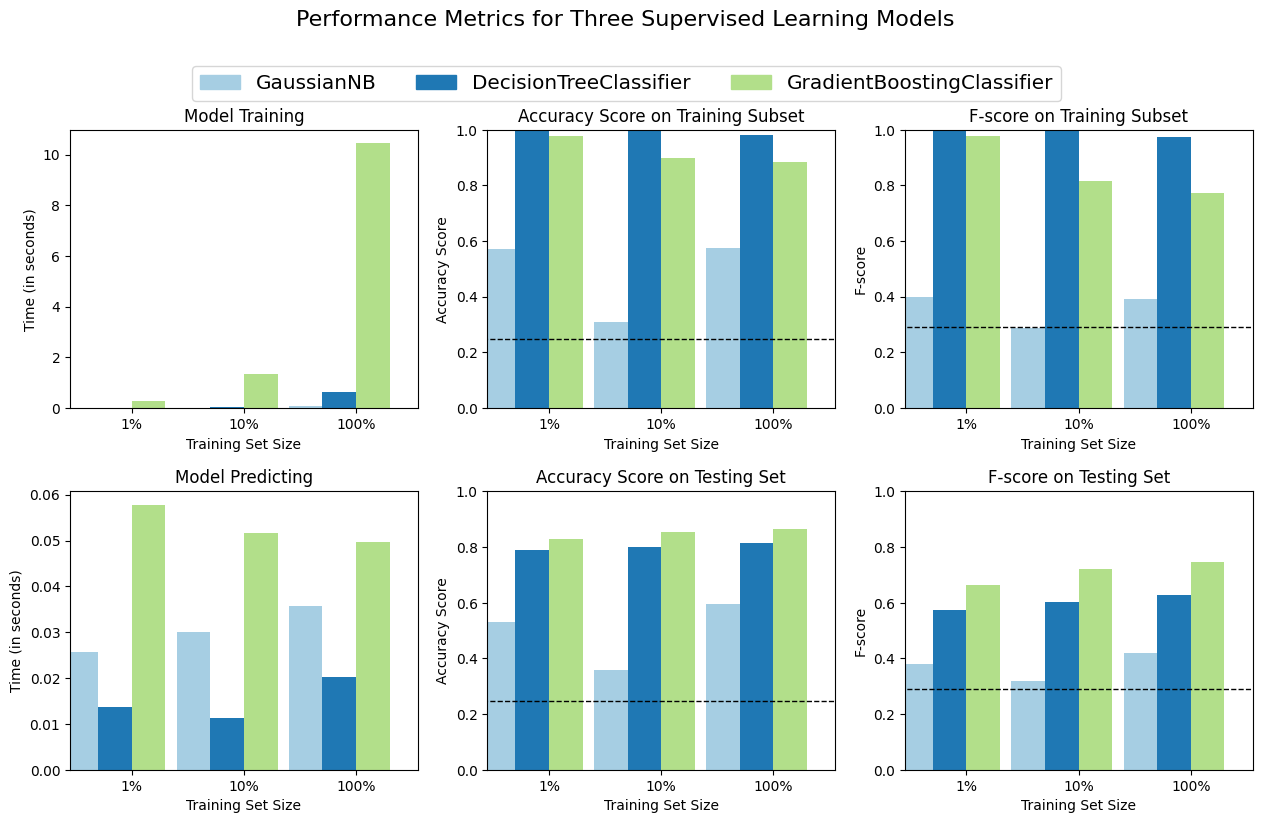

All plotted F-scores are F0.5; prediction times cover test + 300 training rows.


,train_time,pred_time,acc_train,acc_test,f_train,f_test,f1_test
GaussianNB,0.069882,0.035758,0.573333,0.594030,0.390244,0.421005,0.528021
DecisionTreeClassifier,0.625550,0.020244,0.980000,0.815368,0.972222,0.627634,0.621315
GradientBoostingClassifier,10.458612,0.049731,0.883333,0.863903,0.772059,0.746076,0.692788


In [10]:
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score

clf_A = GaussianNB()
clf_B = DecisionTreeClassifier(random_state=0)
clf_C = GradientBoostingClassifier(random_state=0)
models = {m.__class__.__name__: m for m in [clf_A, clf_B, clf_C]}
samples_100 = len(y_train)
samples_10 = int(samples_100 * 0.10)
samples_1 = int(samples_100 * 0.01)

# Select the model family using training data only, with fold-local preprocessing.
scorer = make_scorer(fbeta_score, beta=0.5, zero_division=0)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=0)
cv_rows = []
for name, candidate in models.items():
    pipe = Pipeline([('preprocess', CensusPreprocessor()), ('model', clone(candidate))])
    scores = cross_val_score(pipe, raw_train, y_train, cv=cv, scoring=scorer, n_jobs=1)
    cv_rows.append({'model': name, 'mean_F0.5': scores.mean(), 'std_F0.5': scores.std()})
cv_table = pd.DataFrame(cv_rows).set_index('model')
chosen_name = cv_table['mean_F0.5'].idxmax()
display(cv_table.round(6))
print('Selected by training-only cross-validation:', chosen_name)

results = {}
for name, candidate in models.items():
    results[name] = {}
    for i, samples in enumerate([samples_1, samples_10, samples_100]):
        results[name][i] = train_predict(candidate, samples, X_train, y_train, X_test, y_test)
vs.evaluate(results, accuracy, fscore)
print('All plotted F-scores are F0.5; prediction times cover test + 300 training rows.')
full_comparison = pd.DataFrame({name: runs[2] for name, runs in results.items()}).T
display(full_comparison.round(6))

----
## Improving Results
In this final section, you will choose from the three supervised learning models the *best* model to use on the student data. You will then perform a grid search optimization for the model over the entire training set (`X_train` and `y_train`) by tuning at least one parameter to improve upon the untuned model's F-score. 

### Question 3 - Choosing the Best Model

* Based on the evaluation you performed earlier, in one to two paragraphs, explain to *CharityML* which of the three models you believe to be most appropriate for the task of identifying individuals that make more than $50,000. 

**HINT:** 
Look at the graph at the bottom left from the cell above(the visualization created by `vs.evaluate(results, accuracy, fscore)`) and check the F score for the testing set when 100% of the training set is used. Which model has the highest score? Your answer should include discussion of the:
* metrics - F score on the testing when 100% of the training data is used, 
* prediction/training time
* the algorithm's suitability for the data.

**Answer:** I choose **GradientBoostingClassifier**. With 100% of the training
set, its holdout F₀.₅ is **0.7461**, versus GaussianNB: 0.4210, DecisionTreeClassifier: 0.6276.
It also has the highest mean training-only cross-validation F₀.₅,
**0.7462**; that CV comparison determines the choice before
the holdout comparison is displayed. Its holdout accuracy is **0.8639**.
The ensemble can learn nonlinear combinations of
education, capital gains, and other attributes without a Gaussian independence assumption.
The default decision tree's training/holdout gap provides evidence about its tendency to
overfit; the displayed first-300-row training score is only a diagnostic.

Gradient boosting takes **10.459 seconds** to fit and
**0.050 seconds** to predict the holdout plus 300 training rows in this
run. Naive Bayes takes 0.070 seconds to fit and
0.036 seconds to predict; the decision tree takes
0.626 and
0.020 seconds respectively. The added
training cost is reasonable for this dataset given the stronger precision-weighted score,
since training need not occur for every mailing. These measurements exclude preprocessing
and do not establish performance at the scale of 15 million people.

### Question 4 - Describing the Model in Layman's Terms

* In one to two paragraphs, explain to *CharityML*, in layman's terms, how the final model chosen is supposed to work. Be sure that you are describing the major qualities of the model, such as how the model is trained and how the model makes a prediction. Avoid using advanced mathematical jargon, such as describing equations.

**HINT:**

When explaining your model, if using external resources please include all citations.

**Answer:** Gradient boosting learns from examples of people whose income group is already
known. It starts with a simple estimate, then adds a series of small sets of branching
questions, such as whether someone has many years of education or a large capital gain.
Each new set of questions helps correct the errors still left by the earlier ones.
Combining many modest corrections can capture patterns that one set of rules misses.

For a new person, the model combines the contributions from all these small trees into
an estimated chance of earning above $50,000. At the default decision threshold it
assigns an income group. CharityML could use the higher-income group to prioritize
letters, but a predicted income group does not promise a donation.
Reference: [GradientBoostingClassifier](https://scikit-learn.org/1.4/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html).

### Implementation: Model Tuning

Tune the selected learner with GridSearchCV, using three-fold stratified cross-validation
on all training rows and F₀.₅ as the selection score. The candidate grid is specified before
evaluating tuned holdout performance. For gradient boosting, test **50, 100, and 200 trees**
and tree depths **2 and 3** (six configurations, eighteen CV fits). The default configuration
is included. Do not tune max_features or the decision threshold.

GridSearchCV receives raw training features so imputation, scaling, and dummy encoding
are fitted independently inside each fold. After choosing settings, its refit uses all
training rows. Report both F₀.₅ and F₁ in addition to accuracy, precision, and recall.

Best parameters: {'model__max_depth': 3, 'model__n_estimators': 200}
Best mean CV F0.5: 0.747822; search time: 181.45s


,params,mean_test_score,std_test_score,mean_train_score,mean_fit_time,rank_test_score
5,"{'model__max_depth': 3, 'model__n_estimators':...",0.747822,0.007092,0.764909,15.672190,1
4,"{'model__max_depth': 3, 'model__n_estimators':...",0.746226,0.007147,0.753091,8.345476,2
2,"{'model__max_depth': 2, 'model__n_estimators':...",0.740712,0.009114,0.748794,10.942317,3
3,"{'model__max_depth': 3, 'model__n_estimators':...",0.738183,0.013345,0.742208,4.375337,4
1,"{'model__max_depth': 2, 'model__n_estimators':...",0.734410,0.009321,0.739373,5.772605,5
0,"{'model__max_depth': 2, 'model__n_estimators':...",0.727762,0.011710,0.729160,3.358260,6


,Naive (test),Unoptimized,Optimized
Accuracy,0.247872,0.863903,0.869099
F0.5,0.291760,0.746076,0.754315
F1,0.397271,0.692788,0.710230
Precision,0.247872,0.786402,0.786876
Recall,1.000000,0.619090,0.647190


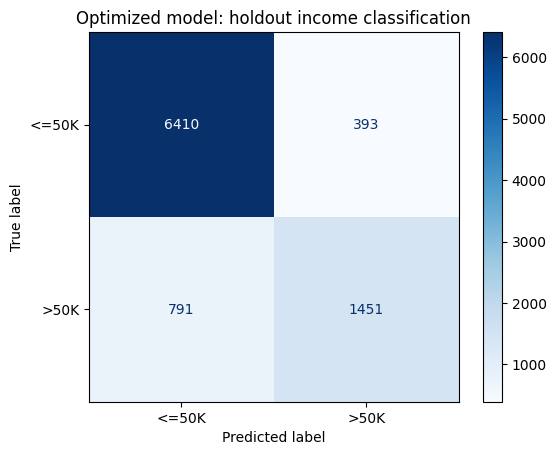

Hypothetical mailing rule on 9,045 holdout people: send 1,844 letters; reduce letters by 79.61%.
Selected: 1,451 higher-income and 393 lower-income people; missed: 791 higher-income people. These are income outcomes, not donations.


In [11]:
from sklearn.model_selection import GridSearchCV

clf = clone(models[chosen_name])
grids = {
    'GradientBoostingClassifier': {'model__n_estimators': [50, 100, 200], 'model__max_depth': [2, 3]},
    'DecisionTreeClassifier': {'model__max_depth': [3, 6, None], 'model__min_samples_leaf': [1, 10]},
    'GaussianNB': {'model__var_smoothing': [1e-11, 1e-9, 1e-7]},
}
parameters = grids[chosen_name]
grid_obj = GridSearchCV(
    Pipeline([('preprocess', CensusPreprocessor()), ('model', clf)]),
    param_grid=parameters, scoring=scorer, cv=cv, n_jobs=1, refit=True,
    return_train_score=True, error_score='raise')
start = time()
grid_fit = grid_obj.fit(raw_train, y_train)
grid_seconds = time() - start
best_pipeline = grid_fit.best_estimator_
best_clf = best_pipeline.named_steps['model']
print('Best parameters:', grid_fit.best_params_)
print(f'Best mean CV F0.5: {grid_fit.best_score_:.6f}; search time: {grid_seconds:.2f}s')
cv_results = pd.DataFrame(grid_fit.cv_results_)
display(cv_results[['params', 'mean_test_score', 'std_test_score', 'mean_train_score',
                    'mean_fit_time', 'rank_test_score']].sort_values('rank_test_score'))

unoptimized = clone(clf).fit(X_train, y_train)
predictions = unoptimized.predict(X_test)
best_predictions = best_pipeline.predict(raw_test)
# Confirm the independently fitted full-training preprocessing has identical columns/values.
pd.testing.assert_frame_equal(best_pipeline.named_steps['preprocess'].transform(raw_train), X_train)

def metrics(y, pred):
    return {'Accuracy': accuracy_score(y, pred),
            'F0.5': fbeta_score(y, pred, beta=0.5, zero_division=0),
            'F1': f1_score(y, pred, zero_division=0),
            'Precision': precision_score(y, pred, zero_division=0),
            'Recall': recall_score(y, pred, zero_division=0)}

evaluation = pd.DataFrame({
    'Naive (test)': metrics(y_test, np.ones(len(y_test), dtype=int)),
    'Unoptimized': metrics(y_test, predictions),
    'Optimized': metrics(y_test, best_predictions),
})
display(evaluation.round(6))
cm = confusion_matrix(y_test, best_predictions)
ConfusionMatrixDisplay(cm, display_labels=['<=50K', '>50K']).plot(cmap='Blues', values_format='d')
plt.title('Optimized model: holdout income classification')
plt.show()
tn, fp, fn, tp = cm.ravel()
letters = int(np.sum(best_predictions))
print(f'Hypothetical mailing rule on {len(y_test):,} holdout people: send {letters:,} letters; '
      f'reduce letters by {1-letters/len(y_test):.2%}.')
print(f'Selected: {tp:,} higher-income and {fp:,} lower-income people; '
      f'missed: {fn:,} higher-income people. These are income outcomes, not donations.')

### Question 5 - Final Model Evaluation

* What is your optimized model's accuracy and F-score on the testing data? 
* Are these scores better or worse than the unoptimized model? 
* How do the results from your optimized model compare to the naive predictor benchmarks you found earlier in **Question 1**?  

**Note:** Fill in the table below with your results, and then provide discussion in the **Answer** box.

#### Results (same holdout set)

| Metric | Unoptimized Model | Optimized Model |
| :--- | ---: | ---: |
| Accuracy | 0.863903 | 0.869099 |
| F0.5 | 0.746076 | 0.754315 |
| F1 | 0.692788 | 0.710230 |
| Precision | 0.786402 | 0.786876 |
| Recall | 0.619090 | 0.647190 |

F0.5 is the notebook's requested F-score; F1 is included for the supplied rubric.

**Answer:** Grid search selects **max_depth=3, n_estimators=200**, with mean three-fold training
CV F₀.₅ **0.747822**. On the holdout, Accuracy increases by 0.005196; F0.5 increases by 0.008239; F1 increases by 0.017442 relative to the untuned model.
The settings were chosen using CV scores, not these holdout results, and the grid includes
the original default configuration. Cross-validation estimates improvement on average;
it does not guarantee a gain on every metric or every future sample.

The optimized accuracy **0.869099**, F₀.₅ **0.754315**, and
F₁ **0.710230** all exceed the always-positive full-dataset benchmarks
(0.247844, 0.291729, and 0.397236, respectively).
The executable results also include an always-positive baseline on exactly the same test
rows for a like-for-like comparison. This substantial gain shows the features contain
useful income-classification information beyond sending letters to everyone.

Applying the optimized classification rule to 9,045 holdout people would
select **1,844** letters, a **79.61%** reduction versus
mailing everyone. Among those selected, 1,451 earn above $50,000 and 393 do not;
791 higher-income people would be missed. Precision is **78.69%** and
recall **64.72%**. These are income classifications; no donation-yield or
dollar-savings estimate is supported without donation and mailing-cost data.

----
## Feature Importance

An important task when performing supervised learning on a dataset like the census data we study here is determining which features provide the most predictive power. By focusing on the relationship between only a few crucial features and the target label we simplify our understanding of the phenomenon, which is most always a useful thing to do. In the case of this project, that means we wish to identify a small number of features that most strongly predict whether an individual makes at most or more than $50,000.

Choose a scikit-learn classifier (e.g., adaboost, random forests) that has a `feature_importance_` attribute, which is a function that ranks the importance of features according to the chosen classifier.  In the next python cell fit this classifier to training set and use this attribute to determine the top 5 most important features for the census dataset.

### Question 6 - Feature Relevance Observation
When **Exploring the Data**, it was shown there are thirteen available features for each individual on record in the census data. Of these thirteen records, which five features do you believe to be most important for prediction, and in what order would you rank them and why?

**Answer:** My five hypotheses, ranked before examining model importances, are:

1. **capital-gain:** Realized investment gains may distinguish people with substantial
   financial resources, although zero gains do not imply low earnings.
2. **education-num:** More education can provide access to specialized, higher-paying work.
3. **occupation:** Job types differ in typical compensation and required skills.
4. **age:** Age can approximate career experience and seniority, with a nonlinear effect
   near retirement.
5. **hours-per-week:** More hours can increase annual earnings, although hourly pay varies.

These are predictive hypotheses, not causal claims. The original data actually contains
**14 input columns** (the starter prose says thirteen); education_level and education-num
are two related representations of education. This ranking names original attributes,
whereas the next chart ranks individual encoded columns, so one categorical attribute can
have its importance divided across several indicators.

### Implementation - Extracting Feature Importance
Choose a `scikit-learn` supervised learning algorithm that has a `feature_importance_` attribute availble for it. This attribute is a function that ranks the importance of each feature when making predictions based on the chosen algorithm.

In the code cell below, you will need to implement the following:
 - Import a supervised learning model from sklearn if it is different from the three used earlier.
 - Train the supervised model on the entire training set.
 - Extract the feature importances using `.feature_importances_`.

,Importance
marital-status_Married-civ-spouse,0.380427
capital-gain,0.203279
education-num,0.197761
capital-loss,0.063201
age,0.055198
hours-per-week,0.034394
occupation_Exec-managerial,0.015899
occupation_Prof-specialty,0.007049
occupation_Other-service,0.006779
workclass_Self-emp-not-inc,0.004721


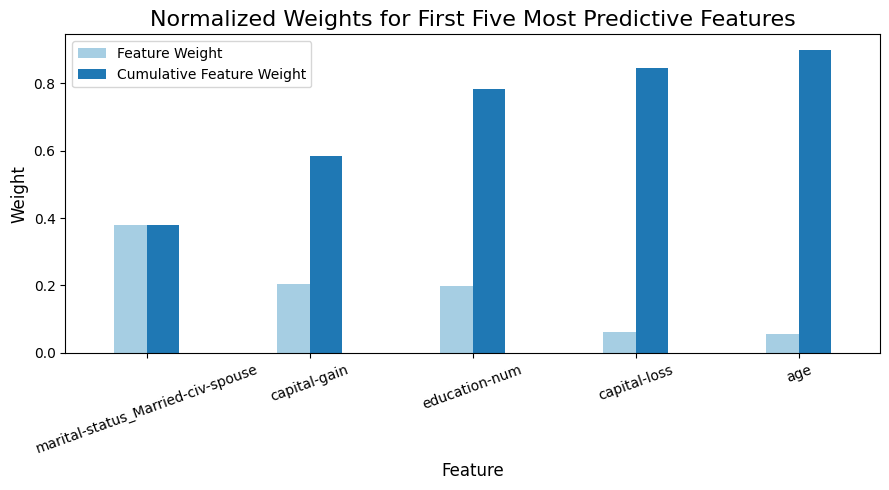

Top-five cumulative importance: 0.8999


In [12]:
# Use the chosen optimized tree ensemble; fall back to a tree if the selected learner
# does not expose importances. Fit only the training set.
importance_estimator = best_clf if hasattr(best_clf, 'feature_importances_') else clf_B
model = clone(importance_estimator).fit(X_train, y_train)
importances = model.feature_importances_
assert len(importances) == X_train.shape[1]
assert np.isclose(importances.sum(), 1.0)
top5 = X_train.columns[np.argsort(importances)[::-1][:5]].tolist()
importance_table = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)
display(importance_table.head(10).rename('Importance').to_frame())
vs.feature_plot(importances, X_train, y_train)
print(f'Top-five cumulative importance: {importance_table.head(5).sum():.4f}')

### Question 7 - Extracting Feature Importance

Observe the visualization created above which displays the five most relevant features for predicting if an individual makes at most or above $50,000.  
* How do these five features compare to the five features you discussed in **Question 6**?
* If you were close to the same answer, how does this visualization confirm your thoughts? 
* If you were not close, why do you think these features are more relevant?

**Answer:** The fitted model ranks these five encoded features, in order:
**marital-status_Married-civ-spouse** (0.3804), **capital-gain** (0.2033), **education-num** (0.1978), **capital-loss** (0.0632), **age** (0.0552). Together they account for **89.99%** of its impurity-based
importance.

The overlap with my original ranking is **capital-gain, education-num, age**. This supports the idea
that investment income and education can be informative. My hypothesized features
**occupation, hours-per-week** do not all appear among these five individual columns. Family or
marital-status indicators can capture strong associations in this census sample that my
initial ranking underestimated; these are associations, not evidence that changing family
status causes income to change. Capital-loss also enters the top five: one plausible
interpretation is that realized losses identify investment activity, even when gains are
zero; the importance score alone does not establish that explanation. A categorical
attribute such as occupation has many dummy
columns, so its total influence can be split across them, unlike a single numeric feature.

The chart measures the fitted model's use of features, not their intrinsic or causal
importance. Correlated predictors can share or substitute for one another, and impurity
importance can favor attributes offering many split points. A permutation-importance
analysis on separate validation data would be a useful follow-up; it was not used to
choose the five columns here.
Reference: [scikit-learn: tree-ensemble feature importance](https://scikit-learn.org/1.4/modules/ensemble.html#feature-importance-evaluation).

### Feature Selection

Use the five encoded columns with highest training-only importance. Refit a clone of the
optimized estimator with the same hyperparameters on those five columns. Compare a fresh
full-feature fit under the same timing conditions, excluding preprocessing and grid search.
Keep hyperparameters fixed to isolate the effect of removing features.

In [13]:
X_train_reduced = X_train.loc[:, top5]
X_test_reduced = X_test.loc[:, top5]
start = time()
full_refit = clone(best_clf).fit(X_train, y_train)
full_fit_seconds = time() - start
start = time()
full_refit_predictions = full_refit.predict(X_test)
full_predict_seconds = time() - start
assert np.array_equal(full_refit_predictions, best_predictions)

start = time()
reduced_clf = clone(best_clf).fit(X_train_reduced, y_train)
reduced_fit_seconds = time() - start
start = time()
reduced_predictions = reduced_clf.predict(X_test_reduced)
reduced_predict_seconds = time() - start
feature_comparison = pd.DataFrame({
    'All features': {**metrics(y_test, best_predictions), 'Fit seconds': full_fit_seconds,
                     'Predict seconds': full_predict_seconds, 'Feature count': X_train.shape[1]},
    'Top five': {**metrics(y_test, reduced_predictions), 'Fit seconds': reduced_fit_seconds,
                 'Predict seconds': reduced_predict_seconds, 'Feature count': 5},
})
display(feature_comparison.round(6))

,All features,Top five
Accuracy,0.869099,0.859701
F0.5,0.754315,0.733347
F1,0.710230,0.687515
Precision,0.786876,0.767455
Recall,0.647190,0.622658
Fit seconds,24.705118,6.202182
Predict seconds,0.088794,0.047756
Feature count,102.000000,5.000000


### Question 8 - Effects of Feature Selection

* How does the final model's F-score and accuracy score on the reduced data using only five features compare to those same scores when all features are used?
* If training time was a factor, would you consider using the reduced data as your training set?

**Answer:** Reducing **102 training-schema encoded features to five** changes holdout
accuracy from **0.869099** to **0.859701**, F₀.₅ from
**0.754315** to **0.733347**, and F₁ from **0.710230** to
**0.687515**. The F₀.₅ change is
**-0.020967**; the accuracy change is
**-0.009397**. Both versions use the same optimized
hyperparameters, so this comparison tests feature removal rather than retuning. The
assignment-visible encoding has 103 columns; model evaluation uses
only the 102 columns learned from training rows, as explained in preprocessing.

Training takes **24.705s** with all features and
**6.202s** with five, a **3.98×** speed ratio in this run.
Holdout prediction takes 0.0888s and
0.0478s respectively. These are single-run measurements and omit
preprocessing and the initial feature-ranking cost. I would consider the reduced model
when frequent retraining or limited computing resources makes this saving worthwhile,
but would retain all features for the main recommendation when mailing precision matters
more than a short training-time saving. Feature importances come only from training data;
the five-feature model's lower-dimensional representation may also simplify future data
collection, provided the required original fields are available.

## Interpretation and limitations

F₀.₅ favors accurate identification of higher-income people, but it does not optimize net
donations directly. The dataset contains neither donation outcomes nor mailing costs.
Historical census relationships may not represent current California residents. Protected
attributes and proxies appear in the data; this classroom exercise is not evidence of
fairness or readiness for deployment. Before operational use, evaluate on contemporary,
representative data with actual donation outcomes and subgroup error rates.

Duplicate feature/label rows are retained because there is no person identifier to tell
whether they are accidental duplicates or different people with identical attributes.
This can make random-split scores optimistic. Repeated holdout comparisons and model-family
selection using the same CV folds also limit claims about generalization. A new external
test set or nested cross-validation would give a stronger final estimate.

The optional unlabeled competition data below provides predictions only; without its true
income labels we cannot calculate accuracy, F-scores, or a leaderboard rank locally.

## Optional extension: competition-format predictions

Use the two additional files provided in the official repository. Preserve test IDs and
row order. Strip surrounding whitespace, recognize `?`/empty entries, fill numerical
missing values with training medians and categorical missing values with training modes,
and align the one-hot columns to the fitted training schema. Refit the selected pipeline
on all labeled census rows only **after** completing evaluation; never fit on competition
rows. This deployment refit is distinct from the model used for the reported holdout scores.

The course notes say the [competition](https://www.kaggle.com/c/udacity-mlcharity-competition)
has ended. The local CSV has the supplied template's format; no leaderboard submission or
score is claimed. Missing-value handling follows the same training-only approach as the
[scikit-learn preprocessing guidance](https://scikit-learn.org/1.4/common_pitfalls.html#data-leakage).


In [14]:
competition_summary = {'status': 'skipped: optional inputs not present'}
if Path('test_census.csv').exists() and Path('example_submission.csv').exists():
    competition = pd.read_csv('test_census.csv', skipinitialspace=True, na_values=['?', ''])
    sample = pd.read_csv('example_submission.csv')
    assert sample.columns.tolist() == ['id', 'income']
    assert len(competition) == len(sample)
    id_col = competition.columns[0]
    assert id_col == 'id' or id_col.startswith('Unnamed:')
    assert np.array_equal(competition[id_col].to_numpy(), sample['id'].to_numpy())
    assert sample['id'].is_unique
    competition_features = competition.drop(columns=id_col)
    assert set(competition_features) == set(features_raw)
    competition_features = competition_features.loc[:, features_raw.columns]
    for col in competition_features.select_dtypes(include='object'):
        competition_features[col] = competition_features[col].str.strip().replace({'?': np.nan, '': np.nan})
    missing = competition_features.isna().sum()
    display(missing[missing > 0].rename('Missing values').to_frame())
    deployment_pipeline = clone(best_pipeline).fit(features_raw, income)
    processed_competition = deployment_pipeline.named_steps['preprocess'].transform(competition_features)
    assert np.isfinite(processed_competition.to_numpy()).all()
    competition_predictions = deployment_pipeline.predict(competition_features).astype(int)
    submission = pd.DataFrame({'id': sample['id'], 'income': competition_predictions})
    assert submission.notna().all().all() and set(submission['income'].unique()) <= {0, 1}
    submission.to_csv('kaggle_submission.csv', index=False)
    competition_summary = {'status': 'predictions generated locally', 'rows': len(submission),
                           'missing_values': int(missing.sum()), 'positive_predictions': int(submission['income'].sum())}
    print(competition_summary)
    display(submission.head())
else:
    print(competition_summary['status'])

,Missing values
age,17
workclass,22
education_level,20
education-num,14
marital-status,21
occupation,22
relationship,16
race,19
sex,19
capital-gain,15


{'status': 'predictions generated locally', 'rows': 45222, 'missing_values': 231, 'positive_predictions': 9062}


,id,income
0,0,0
1,1,1
2,2,0
3,3,1
4,4,0


## Reproducibility and rubric checks

The following cell records computed metrics for an auditable report and checks the main
data, score, and submission invariants. The saved report contains the executed outputs;
timings are single-run measurements, not universal performance guarantees.


In [15]:
assert X_train.shape[0] + X_test.shape[0] == n_records
assert features_final.shape[1] == len(encoded) == 103
assert len(models) == 3 and all(len(v) == 3 for v in results.values())
assert any(len(values) >= 3 for values in parameters.values())
assert len(top5) == 5 and X_train_reduced.shape[1] == 5
assert len(best_predictions) == len(y_test)
assert not evaluation.isna().any().any()
summary = {
    'python': sys.version.split()[0],
    'records': n_records, 'positive': n_greater_50k, 'negative': n_at_most_50k,
    'greater_percent': greater_percent, 'features': X_train.shape[1],
    'assignment_features': len(encoded), 'assignment_only_columns': assignment_only_columns,
    'train_rows': len(X_train), 'test_rows': len(X_test),
    'baseline': {'accuracy': accuracy, 'f05': fscore, 'f1': naive_f1},
    'initial': results, 'cv': cv_table.to_dict(orient='index'),
    'chosen': chosen_name, 'best_params': grid_fit.best_params_,
    'best_cv_f05': grid_fit.best_score_, 'grid_seconds': grid_seconds,
    'evaluation': evaluation.to_dict(), 'confusion_matrix': cm.tolist(),
    'top5': importance_table.head(5).to_dict(),
    'feature_comparison': feature_comparison.to_dict(), 'competition': competition_summary,
}
Path('analysis_metrics.json').write_text(json.dumps(summary, indent=2), encoding='utf-8')
print('All data/metric assertions passed. Results saved to analysis_metrics.json.')

All data/metric assertions passed. Results saved to analysis_metrics.json.


## Submission self-assessment

| Rubric item | Evidence in this notebook | Assessment |
| :--- | :--- | :--- |
| Data exploration | Exact record/class counts and positive percentage | Met |
| Data preprocessing | Full 103-column assignment encoding with assertion; separate training-fitted modeling schema and binary income indicator | Met |
| Q1: naive predictor | Derived accuracy, F0.5 and F1, checked against sklearn | Met |
| Q2: model application | Three models, four-part justification and references for each | Met |
| Training/prediction pipeline | Fresh estimators, measured fit/predict times, train/test metrics | Met |
| Initial evaluation | Three default learners on 1%, 10%, 100%; six-panel visualization | Met |
| Q3: model selection | Training CV, holdout metrics, cost and data suitability | Met |
| Q4: plain-language explanation | How training and prediction work | Met |
| Model tuning | GridSearchCV, three tree-count settings, fold-local preprocessing | Met |
| Q5: final evaluation | Populated before/after table; naive comparison and mailing interpretation | Met |
| Q6: initial feature ranking | Five original attributes with rationale | Met |
| Q7: feature importance | feature_importances_, plot and comparison with hypotheses | Met |
| Q8: reduced-feature model | Five-column refit, measured score and timing comparison | Met |
| Submission files | Executed finding_donors.ipynb and report.html | Met |

This is a self-assessment against the supplied rubric, not a guarantee of a reviewer decision.
The optional prediction file has no independently verified competition score.
